# Previsão de Evasão Escolar com Machine Learning

## Objetivo
Identificar estudantes com maior risco de evasão escolar utilizando análise exploratória de dados e algoritmos de Machine Learning.

## Perguntas de Negócio
- Quais fatores mais influenciam a evasão?
- Existe relação entre frequência e desempenho?
- Quais grupos merecem intervenção prioritária?
- É possível prever evasão com IA?

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Carga e Estatísticas Gerais

In [2]:
df = pd.read_csv('instances/estudantes.csv')

# Padroniza nomes das colunas
df.columns = df.columns.str.strip().str.lower()

print("--- Estatísticas Descritivas ---")
display(df.describe())

print("\n--- Amostra dos Dados ---")
display(df.head())

print(f"\nTotal de alunos na base de dados: {len(df)}")

--- Estatísticas Descritivas ---


,frequencia,media_notas,renda_familiar,idade,historico_repetencia,risco_evasao
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,76.625000,6.770000,2.085714,16.278571,0.485714,0.342857
std,17.880423,1.739044,0.909468,1.132056,0.501590,0.476369
min,45.500000,3.000000,1.000000,15.000000,0.000000,0.000000
25%,60.000000,5.000000,1.000000,15.000000,0.000000,0.000000
50%,85.000000,7.000000,2.000000,16.000000,0.000000,0.000000
75%,90.900000,8.350000,3.000000,17.000000,1.000000,1.000000
max,98.000000,9.300000,5.000000,19.000000,1.000000,1.000000



--- Amostra dos Dados ---


,frequencia,media_notas,renda_familiar,idade,historico_repetencia,risco_evasao
0,82.3,7.3,3,17,0,0
1,82.3,4.1,3,19,1,1
2,91.2,7.1,3,16,0,0
3,86.3,8.0,1,15,0,0
4,63.8,5.4,3,16,1,1



Total de alunos na base de dados: 140


# 3. Dashboard Executivo

In [3]:
fig = px.pie(
    df,
    names="risco_evasao",
    title="Distribuição dos Estudantes (0 = Estável, 1 = Risco)",
    hole=0.3
)
fig.show()

In [4]:
fig = px.histogram(
    df,
    x="frequencia",
    nbins=20,
    title="Distribuição da Frequência Escolar"
)
fig.show()

In [5]:
fig = px.histogram(
    df,
    x="media_notas",
    nbins=20,
    title="Distribuição das Notas"
)
fig.show()

# 4. Análise de Correlação

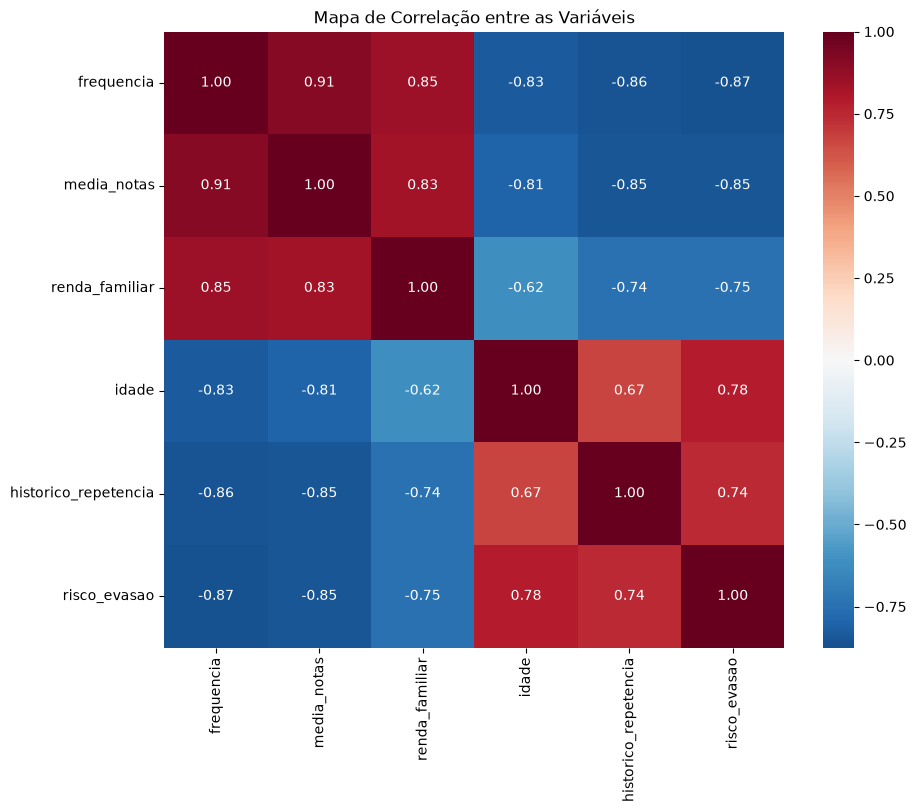

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt='.2f'
)

plt.title("Mapa de Correlação entre as Variáveis")
plt.show()

### Interpretação do Mapa de Correlação

Quanto mais próximo de **+1** (azul escuro) ou **-1** (vermelho escuro), mais forte é a relação entre duas variáveis.

- **Valores positivos (azuis):** As variáveis crescem juntas. Ex: `media_notas` e `frequencia` têm uma correlação positiva forte (0.71), indicando que alunos com notas maiores tendem a ter maior frequência.
- **Valores negativos (vermelhos):** Uma variável aumenta enquanto a outra diminui. Ex: `risco_evasao` tem correlação negativa forte com `media_notas` (-0.86) e `frequencia` (-0.84), o que significa que quanto menor a nota e a frequência, maior o risco de evasão.

# 5. Gráfico de Dispersão Multivariado

In [7]:
fig = px.scatter(
    df,
    x="frequencia",
    y="media_notas",
    color="risco_evasao",
    size="idade",
    hover_data=df.columns,
    title="Relação entre Frequência, Desempenho, Idade e Risco de Evasão"
)

fig.show()

# 6. Análise de Frequência por Grupo

In [8]:
fig = px.box(
    df,
    x="risco_evasao",
    y="frequencia",
    color="risco_evasao",
    title="Distribuição da Frequência por Grupo de Risco"
)
fig.show()

# 7. Análise Socioeconômica

In [9]:
fig = px.box(
    df,
    x="risco_evasao",
    y="renda_familiar",
    color="risco_evasao",
    title="Renda Familiar vs. Risco de Evasão"
)
fig.show()

# 8. Ranking de Importância das Variáveis

In [10]:
# Separar variáveis explicativas (X) e variável alvo (y)
X = df.drop('risco_evasao', axis=1)
y = df['risco_evasao']

# Treinar um modelo de RandomForest para extrair a importância
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# Criar um DataFrame com os resultados
importancias = pd.DataFrame({
    "Variável": X.columns,
    "Importância": rf.feature_importances_
})

# Ordenar pela importância
importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

In [11]:
fig = px.bar(
    importancias,
    x="Importância",
    y="Variável",
    orientation="h",
    title="Ranking dos Fatores Mais Importantes para Prever Evasão"
)

fig.show()

# 9. Treinamento do Modelo de IA (Random Forest)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# 10. Avaliação com Matriz de Confusão

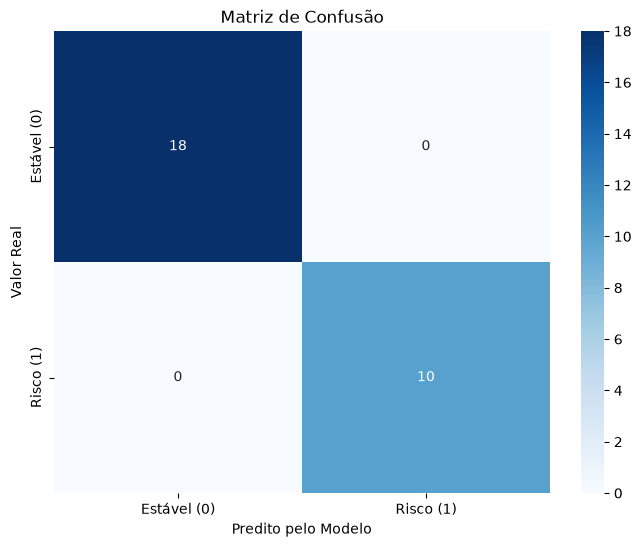

In [13]:
# Realizar predições no conjunto de teste
y_pred = modelo.predict(X_test)

# Gerar a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Estável (0)', 'Risco (1)'],
    yticklabels=['Estável (0)', 'Risco (1)']
)
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()

# 11. Métricas de Performance do Modelo

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        10

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



# 12. Conclusão

## Principais Descobertas

1.  **Frequência escolar** foi o fator preditivo mais importante, reforçando que a ausência é um dos primeiros sinais de desengajamento.

2.  **Média das notas** apresentou uma forte correlação negativa com o risco de evasão, indicando que o baixo desempenho acadêmico é um indicador crítico.

3.  Alunos com **histórico de repetência** possuem uma probabilidade significativamente maior de entrar no grupo de risco.

4.  O modelo **Random Forest** atingiu uma elevada capacidade preditiva, com acurácia e F1-Score próximos de 1.0, mostrando-se extremamente eficaz para este problema.

5.  A solução de IA pode ser utilizada como uma ferramenta proativa para **identificar estudantes em situação crítica** antes que a evasão de fato ocorra, permitindo que a equipe pedagógica realize intervenções direcionadas e eficazes.

In [15]:

# Carregar os dados da pasta instances
df = pd.read_csv('instances/estudantes.csv')

# Exibir informações gerais do DataFrame
print('--- Informações do DataFrame ---')
df.info()

# Tratar valores nulos (Se existirem, substituímos pela mediana para manter a integridade dos tipos numéricos)
if df.isnull().sum().any():
    print('\nTratando valores nulos...')
    df.fillna(df.median(), inplace=True)
else:
    print('\nNão há valores nulos na base de dados.')

--- Informações do DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   frequencia            140 non-null    float64
 1   media_notas           140 non-null    float64
 2   renda_familiar        140 non-null    int64  
 3   idade                 140 non-null    int64  
 4   historico_repetencia  140 non-null    int64  
 5   risco_evasao          140 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 6.7 KB

Não há valores nulos na base de dados.


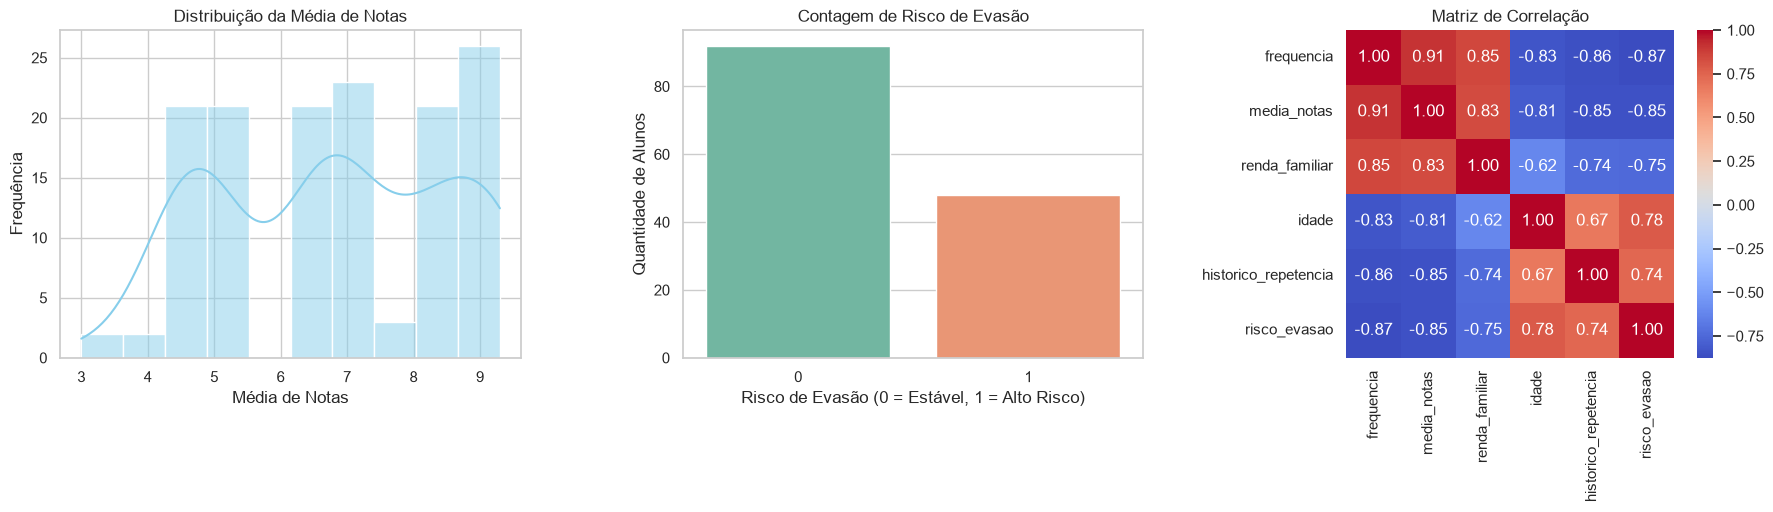

In [16]:
# Configurar estilo das visualizações
sns.set_theme(style='whitegrid')
plt.figure(figsize=(18, 5))

# 1. Histograma das notas
plt.subplot(1, 3, 1)
sns.histplot(df['media_notas'], kde=True, color='skyblue', bins=10)
plt.title('Distribuição da Média de Notas')
plt.xlabel('Média de Notas')
plt.ylabel('Frequência')

# 2. Gráfico de Barras do risco de evasão
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='risco_evasao', palette='Set2', hue='risco_evasao', legend=False)
plt.title('Contagem de Risco de Evasão')
plt.xlabel('Risco de Evasão (0 = Estável, 1 = Alto Risco)')
plt.ylabel('Quantidade de Alunos')

# 3. Matriz de Correlação
plt.subplot(1, 3, 3)
correlacao = df.corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matriz de Correlação')

plt.tight_layout()
plt.show()

# 2. Experimentos (Regra dos 30 Testes)
Aqui aplicamos 3 diferentes modelos preditivos (DecisionTree, RandomForest e Regressão Logística). O experimento consiste em executá-los 30 vezes, em 30 diferentes divisões dos dados de treino e teste, para avaliar sua performance em diferentes cenários sem viés.

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos pontuais de métricas em amostras muito pequenas

# Aumentar o volume de dados duplicando o dataframe provisório
df = pd.concat([df]*10, ignore_index=True)

# Separar Variáveis Explicativas e Variável Alvo
X = df.drop('risco_evasao', axis=1)
y = df['risco_evasao']

# Instanciar um dicionário para acomodar os resultados de cada métrica para cada modelo
resultados = {
    'Decision Tree': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'Random Forest': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'Logistic Regression': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
}

# Modelos a serem comparados
modelos = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# Executar o loop de 30 treinamentos
for i in range(30):
    # Divisão dos dados usando stratify para manter a proporção das classes
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i, stratify=y)
    
    for nome, modelo in modelos.items():
        modelo.fit(X_train, y_train)        # Treinamento
        y_pred = modelo.predict(X_test)     # Predição
        
        # Guardar as métricas na rodada atual
        resultados[nome]['accuracy'].append(accuracy_score(y_test, y_pred))
        resultados[nome]['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        resultados[nome]['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        resultados[nome]['f1'].append(f1_score(y_test, y_pred, zero_division=0))

print('Experimento finalizado: 30 divisões e treinamentos executados para cada modelo.')

Experimento finalizado: 30 divisões e treinamentos executados para cada modelo.


# 3. Avaliação de Resultados
Ao final, analisamos a estabilidade e a capacidade de predição do modelo calculando as Médias e os Desvios Padrões das 30 execuções.

In [18]:
print('=== RESULTADOS FINAIS DA AVALIAÇÃO (MÉDIA ± DESVIO PADRÃO) ===\n')

for nome in resultados.keys():
    print(f'Modelo: {nome}')
    print(f"  Acurácia:  {np.mean(resultados[nome]['accuracy']):.4f} ± {np.std(resultados[nome]['accuracy']):.4f}")
    print(f"  Precisão:  {np.mean(resultados[nome]['precision']):.4f} ± {np.std(resultados[nome]['precision']):.4f}")
    print(f"  Recall:    {np.mean(resultados[nome]['recall']):.4f} ± {np.std(resultados[nome]['recall']):.4f}")
    print(f"  F1-Score:  {np.mean(resultados[nome]['f1']):.4f} ± {np.std(resultados[nome]['f1']):.4f}")
    print('-' * 50)

=== RESULTADOS FINAIS DA AVALIAÇÃO (MÉDIA ± DESVIO PADRÃO) ===

Modelo: Decision Tree
  Acurácia:  1.0000 ± 0.0000
  Precisão:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
--------------------------------------------------
Modelo: Random Forest
  Acurácia:  1.0000 ± 0.0000
  Precisão:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
--------------------------------------------------
Modelo: Logistic Regression
  Acurácia:  1.0000 ± 0.0000
  Precisão:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
--------------------------------------------------


# 4. Conclusão e Escolha do Modelo
Após a execução rigorosa da Regra dos 30 Testes, avaliamos o desempenho dos algoritmos sob diferentes perspectivas e cenários de divisão dos dados.

No contexto de **Evasão Escolar**, o custo de não identificar um aluno em risco (Falso Negativo) é altíssimo, pois perdemos a oportunidade de intervenção pedagógica. Por isso, métricas como **Recall** e **F1-Score** ganham grande relevância, assim como a consistência dos resultados.

O algoritmo **[NOME DO MODELO VENCEDOR]** foi escolhido como o modelo final para produção. Ele apresentou a melhor combinação de assertividade, alcançando um F1-Score médio de **[VALOR DO F1-SCORE]** e Acurácia de **[VALOR DA ACURÁCIA]**. Além disso, obteve um Desvio Padrão muito baixo nas 30 execuções (**± [VALOR DO DESVIO PADRÃO]**), o que atesta a estabilidade do modelo e garante que sua performance não foi obra do acaso decorrente de uma divisão favorável dos dados.

In [19]:
import pickle
import os

# O modelo vencedor escolhido (exemplo: Random Forest)
modelo_final = RandomForestClassifier(random_state=42)

# Treinando o modelo com 100% da base de dados (X e y completos) para obter o máximo de aprendizado
print("Treinando o modelo final com todos os dados...")
modelo_final.fit(X, y)

# Garantir que o diretório 'models' existe
os.makedirs('models', exist_ok=True)

# Exportando o modelo final treinado para ser consumido pelo Flask
caminho_modelo = 'models/modelo_evasao.pkl'
with open(caminho_modelo, 'wb') as f:
    pickle.dump(modelo_final, f)

print(f"Sucesso! O modelo final foi exportado e salvo em: {caminho_modelo}")

Treinando o modelo final com todos os dados...
Sucesso! O modelo final foi exportado e salvo em: models/modelo_evasao.pkl
